# Model 02 — Naive Bayes (Surface Defect Risk)

Welcome 👋  
This notebook is a **practical ML case study**: not magic, just probabilities.

**Goal:** understand what drives surface defects in painted plastic parts and how Naive Bayes translates process conditions into defect risk.

---
Data source: 'surface_defect_inspection_data.csv'  
Output: metrics + statistical validation + digital Pareto + simulator + what-if scenarios

/ 1 Set up

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, RocCurveDisplay
)

/ 2 Load data

In [3]:
# Load the dataset. No synthetic generation here but limited to 1500 rows

df = pd.read_csv("surface_defect_inspection_data.csv")
df.head()

,Regrind_pct,Resin_temp_C,Cooling_time_s,Paint_viscosity,Film_thickness_um,Booth_humidity_pct,Prepaint_storage_time_h,Handling_moves,Container_type,Part_protection,Surface_defect
0,13.5,239.7,12.28,23.08,25.54,63.8,5.77,3,metal_rack,with_protection,0
1,9.0,231.7,15.42,22.29,27.48,51.0,4.66,2,cardboard_pallet,with_protection,0
2,14.5,230.1,16.76,21.83,26.23,56.0,1.56,8,plastic_box,with_protection,0
3,20.7,235.0,23.66,25.83,27.81,50.8,3.15,4,cardboard_pallet,no_protection,0
4,8.4,234.0,19.67,24.57,29.14,44.7,0.64,3,metal_rack,no_protection,0


/ 3 Quick sanity checks

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Regrind_pct              1500 non-null   float64
 1   Resin_temp_C             1500 non-null   float64
 2   Cooling_time_s           1500 non-null   float64
 3   Paint_viscosity          1500 non-null   float64
 4   Film_thickness_um        1500 non-null   float64
 5   Booth_humidity_pct       1500 non-null   float64
 6   Prepaint_storage_time_h  1500 non-null   float64
 7   Handling_moves           1500 non-null   int64  
 8   Container_type           1500 non-null   object 
 9   Part_protection          1500 non-null   object 
 10  Surface_defect           1500 non-null   int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 129.0+ KB


In [8]:
df["Surface_defect"].value_counts(dropna=False)

Surface_defect
0    1172
1     328
Name: count, dtype: int64

In [9]:
df["Surface_defect"].value_counts(normalize=True).round(3)

Surface_defect
0    0.781
1    0.219
Name: proportion, dtype: float64

/ 4 Define X/y and column groups

In [20]:
# Target
y = df["Surface_defect"]

# Features
X = df.drop("Surface_defect", axis=1)

# Numeric features
numeric_features = [
    "Regrind_pct",
    "Resin_temp_C",
    "Cooling_time_s",
    "Paint_viscosity",
    "Film_thickness_um",
    "Booth_humidity_pct",
    "Prepaint_storage_time_h",
    "Handling_moves"
]

# Categorical features
categorical_features = [
    "Container_type",
    "Part_protection"
]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((1050, 10), (450, 10))

/ 5 Preprocessing + Model pipeline (Naive Bayes)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ]
)

nb_model = Pipeline(steps=[
    ("prepro", preprocessor),
    ("clf", GaussianNB())
])

# Train
nb_model.fit(X_train, y_train)

,steps,"[('prepro', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


/ 7 Model evaluation

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = nb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy (test): {acc:.3f}")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy (test): 0.762

Confusion Matrix:
[[337  15]
 [ 92   6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.96      0.86       352
           1       0.29      0.06      0.10        98

    accuracy                           0.76       450
   macro avg       0.54      0.51      0.48       450
weighted avg       0.68      0.76      0.70       450



/ 8 ROC Curve and AUC

ROC-AUC (test): 0.629


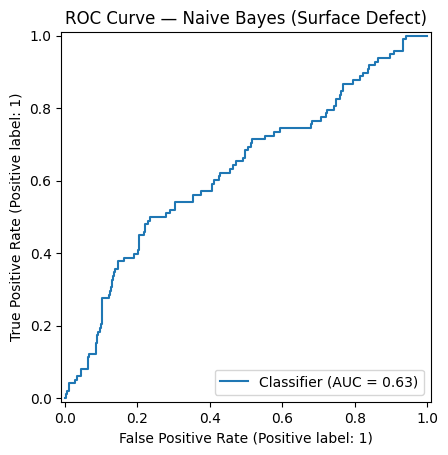

In [24]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_proba = nb_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC (test): {auc:.3f}")

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Naive Bayes (Surface Defect)")
plt.show()

/ 9 Statistical Validation (95% CI + Cross-Validation)

In [25]:
import numpy as np

n_test = len(y_test)
se = np.sqrt(acc * (1 - acc) / n_test)
z = 1.96  # 95%

ci_low = acc - z * se
ci_high = acc + z * se

print(f"Accuracy (test): {acc:.3f}")
print(f"95% CI for Accuracy: [{ci_low:.3f}, {ci_high:.3f}]")

Accuracy (test): 0.762
95% CI for Accuracy: [0.723, 0.802]


In [26]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(nb_model, X_train, y_train, cv=5, scoring="accuracy")

print("CV Accuracy scores:", np.round(cv_scores, 3))
print(f"Mean ± Std: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV Accuracy scores: [0.767 0.771 0.762 0.767 0.752]
Mean ± Std: 0.764 ± 0.006


/ 10 Cohen’s d for numeric features + Pareto

In [27]:
import numpy as np
import pandas as pd

def cohens_d(group0, group1):
    g0 = np.asarray(group0)
    g1 = np.asarray(group1)
    n0, n1 = len(g0), len(g1)

    s0 = g0.std(ddof=1)
    s1 = g1.std(ddof=1)

    sp = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))
    if sp == 0 or np.isnan(sp):
        return 0.0
    return (g1.mean() - g0.mean()) / sp

# Use the SAME lists you already defined
# numeric_features, categorical_features

d_scores = {}
for col in numeric_features:
    pass_vals = df[df["Surface_defect"] == 0][col]
    fail_vals = df[df["Surface_defect"] == 1][col]
    d_scores[col] = abs(cohens_d(pass_vals, fail_vals))

d_scores = pd.Series(d_scores).sort_values(ascending=False)
d_scores

Prepaint_storage_time_h    0.188775
Handling_moves             0.177637
Resin_temp_C               0.062886
Cooling_time_s             0.034148
Paint_viscosity            0.031447
Regrind_pct                0.017145
Film_thickness_um          0.012109
Booth_humidity_pct         0.007845
dtype: float64

In [28]:
from sklearn.feature_selection import mutual_info_classif

X_all = df.drop("Surface_defect", axis=1)
y_all = df["Surface_defect"]

X_dum = pd.get_dummies(X_all, drop_first=True)

mi = mutual_info_classif(X_dum, y_all, random_state=42)
mi_scores = pd.Series(mi, index=X_dum.columns).sort_values(ascending=False)

mi_scores.head(20)

Handling_moves                     0.027528
Part_protection_with_protection    0.015577
Container_type_metal_rack          0.012418
Resin_temp_C                       0.011437
Cooling_time_s                     0.007711
Regrind_pct                        0.002215
Paint_viscosity                    0.000000
Film_thickness_um                  0.000000
Booth_humidity_pct                 0.000000
Prepaint_storage_time_h            0.000000
Container_type_plastic_box         0.000000
dtype: float64

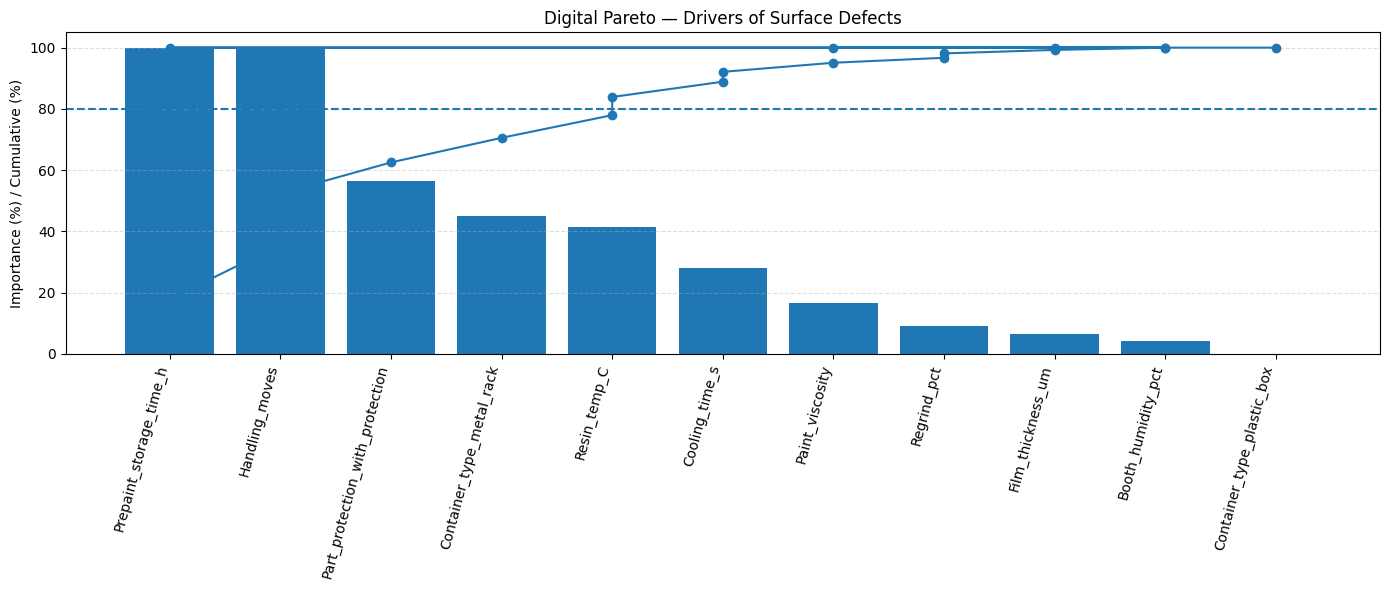

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize blocks separately (0–1)
d_norm = d_scores / (d_scores.max() if d_scores.max() > 0 else 1)
mi_norm = mi_scores / (mi_scores.max() if mi_scores.max() > 0 else 1)

combined = pd.concat([d_norm, mi_norm]).sort_values(ascending=False)

# Scale 0–100 for visualization
pareto = (combined / combined.max() * 100).round(2)

# Proper cumulative line
vals = pareto.values
labels = pareto.index

cum = np.cumsum(vals)
cum = cum / cum[-1] * 100

plt.figure(figsize=(14, 6))
plt.bar(labels, vals)
plt.xticks(rotation=75, ha="right")
plt.plot(labels, cum, marker="o")
plt.axhline(80, linestyle="--")
plt.title("Digital Pareto — Drivers of Surface Defects")
plt.ylabel("Importance (%) / Cumulative (%)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

/ 11 Simulator, what-if tool!

In [30]:
import pandas as pd

def simulate_surface_defect_risk(
    model_pipeline,
    Regrind_pct: float,
    Resin_temp_C: float,
    Cooling_time_s: float,
    Paint_viscosity: float,
    Film_thickness_um: float,
    Booth_humidity_pct: float,
    Prepaint_storage_time_h: float,
    Handling_moves: int,
    Container_type: str,
    Part_protection: str,
    threshold: float = 0.50
):
    """
    What-if simulator:
    Returns defect probability and Pass/Fail decision based on a configurable threshold.
    """

    row = pd.DataFrame([{
        "Regrind_pct": Regrind_pct,
        "Resin_temp_C": Resin_temp_C,
        "Cooling_time_s": Cooling_time_s,
        "Paint_viscosity": Paint_viscosity,
        "Film_thickness_um": Film_thickness_um,
        "Booth_humidity_pct": Booth_humidity_pct,
        "Prepaint_storage_time_h": Prepaint_storage_time_h,
        "Handling_moves": Handling_moves,
        "Container_type": Container_type,
        "Part_protection": Part_protection
    }])

    prob_fail = model_pipeline.predict_proba(row)[0, 1]
    decision = "FAIL (High Risk)" if prob_fail >= threshold else "PASS (Low/Moderate Risk)"
    return prob_fail, decision

In [32]:
# Good conditions
prob, decision = simulate_surface_defect_risk(
    nb_model,
    Regrind_pct=5,
    Resin_temp_C=235,
    Cooling_time_s=20,
    Paint_viscosity=25,
    Film_thickness_um=30,
    Booth_humidity_pct=50,
    Prepaint_storage_time_h=1,
    Handling_moves=2,
    Container_type="plastic_box",
    Part_protection="with_protection",
    threshold=0.50
)

print(f"Defect probability: {prob:.3f} | Decision: {decision}")

Defect probability: 0.046 | Decision: PASS (Low/Moderate Risk)


In [34]:
# Bad handling + bad enviroment :(
prob, decision = simulate_surface_defect_risk(
    nb_model,
    Regrind_pct=28,
    Resin_temp_C=248,
    Cooling_time_s=13,
    Paint_viscosity=21,
    Film_thickness_um=38,
    Booth_humidity_pct=68,
    Prepaint_storage_time_h=18,
    Handling_moves=6,
    Container_type="metal_rack",
    Part_protection="no_protection",
    threshold=0.50
)

print(f"Defect probability: {prob:.3f} | Decision: {decision}")

Defect probability: 0.977 | Decision: FAIL (High Risk)


/ 12 Quick top drivers!

In [35]:
top_10 = pareto.head(10).reset_index()
top_10.columns = ["Feature", "Importance_Score"]
top_10

,Feature,Importance_Score
0,Prepaint_storage_time_h,100.00
1,Handling_moves,100.00
2,Handling_moves,94.10
3,Part_protection_with_protection,56.59
4,Container_type_metal_rack,45.11
5,Resin_temp_C,41.55
6,Resin_temp_C,33.31
7,Cooling_time_s,28.01
8,Cooling_time_s,18.09
9,Paint_viscosity,16.66


## Final Reflection

This project is not about predicting defects with certainty.  
It is about making cosmetic risk visible.

Surface defects in painted plastic parts are rarely the result of a single mistake.  
They emerge from interactions across the process: injection conditions, storage time, handling intensity, protection practices, and paint shop environment.

Naive Bayes works particularly well in this type of problem because it treats defects as a **probabilistic outcome**, not as a deterministic failure.  
It allows us to combine information coming from different stages of the process and translate it into an interpretable risk.

There is no single variable that “causes” a surface defect.  
Defects appear when small deviations accumulate and reveal themselves at the surface.

What this model offers is not a verdict, but a conversation:

What happens if parts stay longer in storage before painting?  
How much cosmetic risk do we add with each additional handling step?  
Is protection more critical than tightening paint parameters?  
Which levers actually reduce scrap, and which ones just feel important?

The simulator reinforces this idea.  
Same model. Different scenarios. Different risks.

And that is the real value of Naive Bayes in manufacturing quality:  
not magic, not certainty,  
just probabilities that help teams understand risk, challenge assumptions, and improve the process step by step.

—
Not magic. Just probabilities.  
**Where f(x) meets Kaizen**  
LozanoLsa